# RQ6: Journal-Safe Weakly Supervised Review-Priority Ranking

**Research Question:** Can a weakly supervised, interpretable **review-priority proxy** be constructed from clause absence, clause category, structural irregularities, and semantic deviation from retrieved reference clauses?

## Journal-safe scope

This notebook does **not** claim true legal risk prediction, legal advice, or real policy-compliance detection.  
It constructs a reproducible **proxy ranking for human review prioritization** using signals that can be derived from public datasets:

1. clause-category attention based on review-sensitive clause types;
2. category absence prevalence at contract level;
3. structural irregularity proxies from lightweight layout features;
4. semantic deviation from the nearest reference clause, preferably from the **same clause label and a different contract**.

The output filenames and output folders are intentionally kept unchanged for compatibility with the existing thesis/paper pipeline:

- `outputs_journal_v2/csv/rq6_proxy_risk_base_signals.csv`
- `outputs_journal_v2/csv/rq6_ranked_proxy_risk_clauses_journal.csv`
- `outputs_journal_v2/csv/rq6_proxy_risk_summary_by_category.csv`
- `outputs_journal_v2/figures/rq6_fig1_proxy_risk_by_category.pdf`
- `outputs_journal_v2/figures/rq6_fig2_proxy_risk_distribution.pdf`


In [1]:
# ============================================================
# Journal-grade common setup
# Uses ONLY local datasets and local SBERT model.
# Expected local structure:
# C:\Users\a2510\Desktop\new_code\
#   ├── cuad\
#   ├── lex_glue\
#   └── all-MiniLM-L6-v2\
# ============================================================

from pathlib import Path
import os, re, json, random, math, warnings, statistics
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split, GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.metrics.pairwise import cosine_similarity

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

try:
    from sentence_transformers import SentenceTransformer
except Exception:
    SentenceTransformer = None

try:
    from rank_bm25 import BM25Okapi
except Exception:
    BM25Okapi = None

try:
    from datasets import load_from_disk
except Exception:
    load_from_disk = None

BASE_DIR = Path.cwd()
CUAD_DIR = BASE_DIR / "cuad"
LEX_DIR = BASE_DIR / "lex_glue"
MODEL_DIR = BASE_DIR / "all-MiniLM-L6-v2"

OUTPUT_DIR = BASE_DIR / "outputs_journal_v2"
CSV_DIR = OUTPUT_DIR / "csv"
FIG_DIR = OUTPUT_DIR / "figures"
CSV_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_REPEATS = 5
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("BASE_DIR:", BASE_DIR)
print("CUDA available / selected device:", DEVICE)
print("CUAD_DIR:", CUAD_DIR, CUAD_DIR.exists())
print("LEX_DIR:", LEX_DIR, LEX_DIR.exists())
print("MODEL_DIR:", MODEL_DIR, MODEL_DIR.exists())
if DEVICE == "cuda":
    try:
        print("GPU:", torch.cuda.get_device_name(0))
    except Exception:
        pass

BASE_DIR: c:\Users\a2510\Desktop\new_code
CUDA available / selected device: cuda
CUAD_DIR: c:\Users\a2510\Desktop\new_code\cuad True
LEX_DIR: c:\Users\a2510\Desktop\new_code\lex_glue True
MODEL_DIR: c:\Users\a2510\Desktop\new_code\all-MiniLM-L6-v2 True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# ============================================================
# Robust local dataset loaders + feature functions
# ============================================================

def clean_text(x):
    if x is None:
        return ""
    if isinstance(x, float) and pd.isna(x):
        return ""
    x = str(x)
    x = x.replace("\x00", " ")
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def normalize_label(label):
    """
    Converts CUAD question-style labels into short clause names when possible.
    Example: Highlight ... related to "Governing Law" ... -> Governing Law
    """
    label = clean_text(label)
    m = re.search(r'"([^"]+)"', label)
    if m:
        return clean_text(m.group(1))
    # remove common CUAD question phrase if present
    label = re.sub(r"(?i)^highlight the parts.*?related to", "", label)
    label = re.sub(r"(?i)that should be reviewed by a lawyer.*$", "", label)
    label = label.strip(" .:-")
    return label if label else "Unknown"

def savecsv(df, filename):
    path = CSV_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("Saved CSV:", path)
    return path

def savefig(filename):
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)
    return path

def find_files(root, suffixes):
    root = Path(root)
    files = []
    if not root.exists():
        return files
    for suf in suffixes:
        files += list(root.rglob(f"*{suf}"))
    return files

def pick_column(cols, candidates):
    cols = list(cols)
    lower = {str(c).lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    for c in cols:
        lc = str(c).lower()
        if any(cand.lower() in lc for cand in candidates):
            return c
    return None

def dataframe_from_hf_dataset(ds):
    frames = []
    if hasattr(ds, "keys") and not isinstance(ds, list):
        # DatasetDict
        for split in ds.keys():
            try:
                frames.append(ds[split].to_pandas())
            except Exception:
                pass
    else:
        try:
            frames.append(ds.to_pandas())
        except Exception:
            pass
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_cuad_samples(cuad_dir=CUAD_DIR, min_len=20):
    """
    Loads real local CUAD data.
    Supports:
    1) HuggingFace load_from_disk Arrow format
    2) CSV/XLSX
    3) SQuAD-style JSON
    Output: contract_id, text, label, raw_label
    """
    cuad_dir = Path(cuad_dir)
    rows = []

    # 1. HuggingFace Arrow/load_from_disk
    if load_from_disk is not None and (cuad_dir / "dataset_info.json").exists():
        try:
            ds = load_from_disk(str(cuad_dir))
            hdf = dataframe_from_hf_dataset(ds)
            if len(hdf) > 0:
                text_col = pick_column(hdf.columns, ["answers", "answer", "text", "context", "clause", "clause_text"])
                label_col = pick_column(hdf.columns, ["question", "label", "category", "clause_category"])
                contract_col = pick_column(hdf.columns, ["title", "contract", "contract_id", "document", "filename"])

                parsed = []
                for _, r in hdf.iterrows():
                    contract_id = clean_text(r[contract_col]) if contract_col else "hf_contract"
                    raw_label = clean_text(r[label_col]) if label_col else "Unknown"
                    label = normalize_label(raw_label)

                    # HuggingFace answer may be dict {'text': [...]} or list
                    val = r[text_col] if text_col else ""
                    if isinstance(val, dict) and "text" in val:
                        texts = val["text"]
                        if not isinstance(texts, list):
                            texts = [texts]
                    elif isinstance(val, list):
                        texts = val
                    else:
                        texts = [val]

                    # If text is empty, fallback to context
                    if not texts or all(len(clean_text(t)) < min_len for t in texts):
                        if "context" in hdf.columns:
                            texts = [r["context"]]

                    for t in texts:
                        t = clean_text(t)
                        if len(t) >= min_len:
                            parsed.append({"contract_id": contract_id, "text": t, "raw_label": raw_label, "label": label})
                if parsed:
                    rows.append(pd.DataFrame(parsed))
        except Exception as e:
            print("HF CUAD loading failed, trying files:", e)

    # 2. Tabular files recursively
    for fp in find_files(cuad_dir, [".csv", ".xlsx", ".xls"]):
        try:
            df = pd.read_csv(fp) if fp.suffix.lower()==".csv" else pd.read_excel(fp)
        except Exception:
            continue
        text_col = pick_column(df.columns, ["answer", "answers", "clause", "clause_text", "text", "context", "excerpt", "span"])
        label_col = pick_column(df.columns, ["category", "clause_category", "label", "question", "clause type", "clause_type"])
        contract_col = pick_column(df.columns, ["contract", "contract_id", "document", "document_id", "file", "filename", "title"])
        if text_col and label_col:
            tmp = pd.DataFrame()
            tmp["text"] = df[text_col].apply(clean_text)
            tmp["raw_label"] = df[label_col].apply(clean_text)
            tmp["label"] = tmp["raw_label"].apply(normalize_label)
            tmp["contract_id"] = df[contract_col].astype(str) if contract_col else fp.stem
            tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
            if len(tmp):
                rows.append(tmp[["contract_id", "text", "raw_label", "label"]])

    # 3. SQuAD JSON recursively
    for fp in find_files(cuad_dir, [".json"]):
        try:
            obj = json.loads(fp.read_text(encoding="utf-8"))
        except Exception:
            try:
                obj = json.loads(fp.read_text(encoding="latin-1"))
            except Exception:
                continue
        if not isinstance(obj, dict) or "data" not in obj:
            continue
        parsed = []
        for doc in obj.get("data", []):
            contract_id = clean_text(doc.get("title", fp.stem))
            for para in doc.get("paragraphs", []):
                context = clean_text(para.get("context", ""))
                for qa in para.get("qas", []):
                    raw_label = clean_text(qa.get("question", qa.get("id", "Unknown")))
                    label = normalize_label(raw_label)
                    answers = qa.get("answers", [])
                    if answers:
                        for ans in answers:
                            t = clean_text(ans.get("text", ""))
                            if len(t) >= min_len:
                                parsed.append({"contract_id": contract_id, "text": t, "raw_label": raw_label, "label": label})
        if parsed:
            rows.append(pd.DataFrame(parsed))

    if not rows:
        raise FileNotFoundError(f"No usable CUAD samples found in {cuad_dir}. Check folder format.")

    data = pd.concat(rows, ignore_index=True).drop_duplicates()
    data = data[(data["text"].str.len() >= min_len) & (data["label"].str.len() > 0)]
    data = data.reset_index(drop=True)

    print("Loaded real CUAD samples:", data.shape)
    print("Unique short labels:", data["label"].nunique())
    print("Unique contracts:", data["contract_id"].nunique())
    print(data["label"].value_counts().head(10))
    return data

def load_lexglue_samples(lex_dir=LEX_DIR, subset_keywords=("ledgar", "unfair"), min_len=10):
    """
    Loads real local LexGLUE data from subfolders.
    Supports HF Arrow/load_from_disk and CSV/JSON/JSONL.
    Output: subset, text, label
    """
    lex_dir = Path(lex_dir)
    rows = []

    # Try each immediate subfolder as HF dataset
    if load_from_disk is not None:
        candidates = [p for p in lex_dir.rglob("*") if p.is_dir() and (p / "dataset_info.json").exists()]
        for p in candidates:
            low = str(p).lower()
            if not any(k.lower() in low for k in subset_keywords):
                continue
            try:
                ds = load_from_disk(str(p))
                df = dataframe_from_hf_dataset(ds)
                if len(df) == 0:
                    continue
                text_col = pick_column(df.columns, ["text", "sentence", "paragraph", "provision", "clause", "context"])
                label_col = pick_column(df.columns, ["label", "labels", "category", "answer", "class"])
                if text_col and label_col:
                    tmp = pd.DataFrame({
                        "subset": p.name,
                        "text": df[text_col].apply(clean_text),
                        "label": df[label_col].astype(str).apply(clean_text)
                    })
                    tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
                    rows.append(tmp)
            except Exception:
                pass

    for fp in find_files(lex_dir, [".csv", ".jsonl", ".json"]):
        low = str(fp).lower()
        if not any(k.lower() in low for k in subset_keywords):
            continue
        try:
            if fp.suffix.lower() == ".csv":
                df = pd.read_csv(fp)
            elif fp.suffix.lower() == ".jsonl":
                df = pd.read_json(fp, lines=True)
            else:
                obj = json.loads(fp.read_text(encoding="utf-8"))
                if isinstance(obj, list):
                    df = pd.DataFrame(obj)
                elif isinstance(obj, dict) and "data" in obj and isinstance(obj["data"], list):
                    df = pd.DataFrame(obj["data"])
                else:
                    continue
        except Exception:
            continue
        text_col = pick_column(df.columns, ["text", "sentence", "paragraph", "provision", "clause", "context"])
        label_col = pick_column(df.columns, ["label", "labels", "category", "answer", "class"])
        if text_col and label_col:
            tmp = pd.DataFrame({
                "subset": fp.parent.name,
                "text": df[text_col].apply(clean_text),
                "label": df[label_col].astype(str).apply(clean_text)
            })
            tmp = tmp[(tmp["text"].str.len() >= min_len) & (tmp["label"].str.len() > 0)]
            rows.append(tmp)

    if not rows:
        raise FileNotFoundError(f"No usable LexGLUE samples found in {lex_dir} for keywords {subset_keywords}.")

    data = pd.concat(rows, ignore_index=True).drop_duplicates().reset_index(drop=True)
    print("Loaded real LexGLUE samples:", data.shape)
    print(data["subset"].value_counts().head())
    return data

def get_sbert_model():
    if SentenceTransformer is None:
        raise ImportError("sentence-transformers is missing. Run: pip install sentence-transformers")
    if not MODEL_DIR.exists():
        raise FileNotFoundError(f"Local SBERT model folder not found: {MODEL_DIR}")
    return SentenceTransformer(str(MODEL_DIR), device=DEVICE)

def extract_layout_features(df):
    texts = df["text"].fillna("").astype(str)
    group_pos = df.groupby("contract_id").cumcount()
    group_count = df.groupby("contract_id")["text"].transform("count").clip(lower=1)
    rel_position = group_pos / group_count

    feat = pd.DataFrame({
        "clause_length_chars": texts.str.len(),
        "clause_length_words": texts.apply(lambda x: len(x.split())),
        "sentence_count": texts.apply(lambda x: max(1, len(re.findall(r"[.!?;]", x)))),
        "uppercase_ratio": texts.apply(lambda x: sum(ch.isupper() for ch in x) / max(1, len(x))),
        "relative_position": rel_position,
        "has_numbering": texts.str.contains(r"(^|\s)(\d+(\.\d+)*|\([a-zA-Z0-9]+\)|[ivx]+\.)", case=False, regex=True).astype(int),
        "has_heading_keyword": texts.str.contains(r"\b(section|article|clause|schedule|exhibit|annex|appendix)\b", case=False, regex=True).astype(int),
        "has_signature_keyword": texts.str.contains(r"\b(signature|signed|witness|in witness whereof|executed|signatory)\b", case=False, regex=True).astype(int),
        "has_table_like_pattern": texts.str.contains(r"(\t| {3,}|\|)", regex=True).astype(int),
        "has_date": texts.str.contains(r"\b(\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2}|january|february|march|april|may|june|july|august|september|october|november|december)\b", case=False, regex=True).astype(int),
        "has_money": texts.str.contains(r"(\$|€|usd|eur|dollars?|euros?)", case=False, regex=True).astype(int),
        "has_percentage": texts.str.contains(r"\d+(\.\d+)?\s?%", regex=True).astype(int),
        "contains_negation": texts.str.contains(r"\b(no|not|without|unless|except|excluding)\b", case=False, regex=True).astype(int),
        "contains_obligation": texts.str.contains(r"\b(shall|must|required|obligated|agree)\b", case=False, regex=True).astype(int),
    })
    return feat.fillna(0)

def group_split_indices(df, test_size=0.2, seed=42):
    groups = df["contract_id"].astype(str).values
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    train_idx, test_idx = next(splitter.split(df, groups=groups))
    return train_idx, test_idx

def metric_row(y_true, y_pred, model, task="", split_seed=None):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return {
        "task": task,
        "model": model,
        "split_seed": split_seed,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": p,
        "macro_recall": r,
        "macro_f1": f1,
        "micro_f1": f1_score(y_true, y_pred, average="micro")
    }

def repeated_summary(df, metric_cols=("accuracy","macro_f1","micro_f1")):
    rows = []
    for model, g in df.groupby("model"):
        row = {"model": model}
        for col in metric_cols:
            row[col + "_mean"] = g[col].mean()
            row[col + "_std"] = g[col].std(ddof=1) if len(g) > 1 else 0
        rows.append(row)
    return pd.DataFrame(rows).sort_values(metric_cols[1] + "_mean", ascending=False)

In [3]:
# ============================================================
# RQ6 base signals: journal-safe proxy review-priority features
# ------------------------------------------------------------
# Important:
# - This is NOT true legal risk prediction.
# - It is a weakly supervised proxy for prioritizing clauses for
#   additional human review.
# - Existing output filename is preserved:
#   rq6_proxy_risk_base_signals.csv
# ============================================================

df = load_cuad_samples()
layout = extract_layout_features(df)

# Contract-level clause presence/absence matrix.
# This measures how often a clause category is absent across contracts.
presence = pd.crosstab(df["contract_id"], df["label"])
presence = (presence > 0).astype(int)
absence_rate = 1 - presence.mean(axis=0)

# Review-sensitive keywords are used only as a transparent prior.
# They do not represent expert-labelled legal risk.
review_sensitive_keywords = [
    "termination", "indemnification", "liability", "limitation", "confidential",
    "non-compete", "exclusivity", "governing law", "assignment", "change of control",
    "most favored", "audit", "insurance", "warranty", "ip", "intellectual property",
    "ownership", "source code", "escrow", "renewal"
]

risk = df[["contract_id", "label", "text"]].copy()

# Keep the old column name for compatibility, but make its meaning clear.
risk["clause_type_attention"] = risk["label"].str.lower().apply(
    lambda x: 1.0 if any(k in x for k in review_sensitive_keywords) else 0.3
)
risk["review_sensitive_category_score"] = risk["clause_type_attention"]

# Keep the old column name for compatibility.
risk["category_absence_rate"] = risk["label"].map(absence_rate).fillna(0)
risk["category_absence_prevalence"] = risk["category_absence_rate"]

# Layout-derived irregularity proxies.
risk["short_clause_signal"] = (
    layout["clause_length_words"] < layout["clause_length_words"].quantile(0.15)
).astype(float)
risk["late_document_position"] = (layout["relative_position"] > 0.85).astype(float)
risk["no_numbering_signal"] = (layout["has_numbering"] == 0).astype(float)

# Keep the old column name for compatibility.
risk["layout_irregularity"] = risk[
    ["short_clause_signal", "late_document_position", "no_numbering_signal"]
].mean(axis=1)
risk["layout_irregularity_proxy"] = risk["layout_irregularity"]

risk["scope_note"] = (
    "Weakly supervised proxy for review prioritization; "
    "not expert legal risk, not legal advice, not policy-compliance ground truth."
)

base_signals = pd.concat([risk.head(1000), layout.head(1000)], axis=1)
savecsv(base_signals, "rq6_proxy_risk_base_signals.csv")

print("RQ6 base proxy signals created.")
print("Output name preserved: rq6_proxy_risk_base_signals.csv")


Loaded real CUAD samples: (11734, 4)
Unique short labels: 41
Unique contracts: 510
label
Parties                      1121
License Grant                 774
Cap On Liability              672
Anti-Assignment               651
Audit Rights                  642
Insurance                     558
Expiration Date               464
Governing Law                 462
Post-Termination Services     449
Document Name                 441
Name: count, dtype: int64
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq6_proxy_risk_base_signals.csv
RQ6 base proxy signals created.
Output name preserved: rq6_proxy_risk_base_signals.csv


In [4]:
# ============================================================
# RQ6 semantic deviation + proxy review-priority score
# ------------------------------------------------------------
# Journal-safe improvement:
# - Semantic deviation is computed against a reference clause from
#   a different contract.
# - Preference is given to same-label, different-contract references.
# - Fallback to any-label, different-contract reference is explicitly marked.
# - Existing output filenames are preserved:
#   rq6_ranked_proxy_risk_clauses_journal.csv
#   rq6_proxy_risk_summary_by_category.csv
# ============================================================

def minmax_norm(series):
    series = pd.to_numeric(series, errors="coerce")
    mn, mx = series.min(), series.max()
    if pd.isna(mn) or pd.isna(mx) or abs(mx - mn) < 1e-12:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - mn) / (mx - mn + 1e-9)

def bootstrap_ci(values, n_boot=500, seed=42):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(values) == 0:
        return (np.nan, np.nan)
    if len(values) == 1:
        return (float(values[0]), float(values[0]))
    rng = np.random.default_rng(seed)
    means = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        means.append(sample.mean())
    return (float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5)))

sample_n = min(2000, len(risk))
risk_sample = risk.sample(sample_n, random_state=RANDOM_STATE).reset_index(drop=True)

sbert_model = get_sbert_model()
emb = sbert_model.encode(
    risk_sample["text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

contracts = risk_sample["contract_id"].astype(str).to_numpy()
labels = risk_sample["label"].astype(str).to_numpy()

nearest_sim = np.full(sample_n, np.nan, dtype=float)
nearest_ref_label = np.array([""] * sample_n, dtype=object)
nearest_ref_contract = np.array([""] * sample_n, dtype=object)
reference_scope = np.array(["unavailable"] * sample_n, dtype=object)

# 1) Preferred reference: same label, different contract.
for label in pd.unique(labels):
    idx = np.where(labels == label)[0]
    if len(idx) < 2:
        continue

    sub_emb = emb[idx]
    sub_sim = sub_emb @ sub_emb.T
    same_contract = contracts[idx][:, None] == contracts[idx][None, :]
    sub_sim[same_contract] = -np.inf

    best_local = sub_sim.argmax(axis=1)
    best_vals = sub_sim[np.arange(len(idx)), best_local]

    for local_i, global_i in enumerate(idx):
        if np.isfinite(best_vals[local_i]):
            ref_global = idx[best_local[local_i]]
            nearest_sim[global_i] = float(best_vals[local_i])
            nearest_ref_label[global_i] = labels[ref_global]
            nearest_ref_contract[global_i] = contracts[ref_global]
            reference_scope[global_i] = "same_label_different_contract"

# 2) Explicit fallback: any label, different contract.
needs_fallback = np.where(~np.isfinite(nearest_sim))[0]
if len(needs_fallback) > 0:
    all_sim = emb @ emb.T
    same_contract_all = contracts[:, None] == contracts[None, :]
    all_sim[same_contract_all] = -np.inf

    for global_i in needs_fallback:
        best_j = int(np.argmax(all_sim[global_i]))
        best_val = float(all_sim[global_i, best_j])
        if np.isfinite(best_val):
            nearest_sim[global_i] = best_val
            nearest_ref_label[global_i] = labels[best_j]
            nearest_ref_contract[global_i] = contracts[best_j]
            reference_scope[global_i] = "fallback_any_label_different_contract"

# 3) If all samples come from one contract or no valid reference exists, impute conservatively.
if np.any(~np.isfinite(nearest_sim)):
    finite_vals = nearest_sim[np.isfinite(nearest_sim)]
    conservative_similarity = float(np.nanmedian(finite_vals)) if len(finite_vals) else 0.5
    nearest_sim[~np.isfinite(nearest_sim)] = conservative_similarity
    reference_scope[reference_scope == "unavailable"] = "imputed_no_valid_different_contract_reference"

risk_sample["nearest_clause_similarity"] = nearest_sim
risk_sample["nearest_reference_label"] = nearest_ref_label
risk_sample["nearest_reference_contract_id"] = nearest_ref_contract
risk_sample["reference_match_scope"] = reference_scope

# Keep the old column name for compatibility.
risk_sample["semantic_deviation"] = 1 - risk_sample["nearest_clause_similarity"]
risk_sample["semantic_deviation_from_reference"] = risk_sample["semantic_deviation"]

# Normalized components. These are transparent proxy components, not supervised legal-risk labels.
for col in [
    "clause_type_attention",
    "category_absence_rate",
    "layout_irregularity",
    "semantic_deviation"
]:
    risk_sample[col + "_norm"] = minmax_norm(risk_sample[col])

# Fixed interpretable weights. The old column name is preserved.
risk_sample["proxy_risk_score"] = (
    0.30 * risk_sample["clause_type_attention_norm"] +
    0.25 * risk_sample["category_absence_rate_norm"] +
    0.20 * risk_sample["layout_irregularity_norm"] +
    0.25 * risk_sample["semantic_deviation_norm"]
)

# Journal-safe alias: same values, safer terminology.
risk_sample["proxy_review_priority_score"] = risk_sample["proxy_risk_score"]
risk_sample["score_interpretation"] = (
    "Higher value indicates higher weakly supervised review priority; "
    "not a validated legal-risk probability."
)

risk_sample = risk_sample.sort_values("proxy_risk_score", ascending=False).reset_index(drop=True)

category_summary = risk_sample.groupby("label").agg(
    mean_proxy_risk=("proxy_risk_score", "mean"),
    std_proxy_risk=("proxy_risk_score", "std"),
    n=("proxy_risk_score", "count"),
    mean_semantic_deviation=("semantic_deviation", "mean"),
    mean_reference_similarity=("nearest_clause_similarity", "mean"),
    same_label_reference_rate=(
        "reference_match_scope",
        lambda x: np.mean(pd.Series(x).eq("same_label_different_contract"))
    ),
    mean_absence_rate=("category_absence_rate", "mean"),
    mean_layout_irregularity=("layout_irregularity", "mean")
).sort_values("mean_proxy_risk", ascending=False).reset_index()

# Add bootstrap CIs for category-level mean proxy score.
ci_rows = []
for label, g in risk_sample.groupby("label"):
    low, high = bootstrap_ci(g["proxy_risk_score"], seed=RANDOM_STATE)
    ci_rows.append({"label": label, "mean_proxy_risk_ci_low": low, "mean_proxy_risk_ci_high": high})
ci_df = pd.DataFrame(ci_rows)
category_summary = category_summary.merge(ci_df, on="label", how="left")

# Journal-safe risk-level wording: priority bands, not real legal-risk classes.
q_high = risk_sample["proxy_risk_score"].quantile(0.75)
q_low = risk_sample["proxy_risk_score"].quantile(0.25)
risk_sample["proxy_priority_band"] = np.where(
    risk_sample["proxy_risk_score"] >= q_high, "higher-review-priority",
    np.where(risk_sample["proxy_risk_score"] <= q_low, "lower-review-priority", "medium-review-priority")
)

category_summary["journal_safe_note"] = (
    "Category-level weakly supervised proxy for review prioritization; "
    "not expert-labelled legal risk."
)

display(risk_sample.head(20))
display(category_summary.head(20))

savecsv(risk_sample, "rq6_ranked_proxy_risk_clauses_journal.csv")
savecsv(category_summary, "rq6_proxy_risk_summary_by_category.csv")

print("RQ6 journal-safe proxy ranking created.")
print("Output names preserved:")
print("- rq6_ranked_proxy_risk_clauses_journal.csv")
print("- rq6_proxy_risk_summary_by_category.csv")
print("\nReference scope distribution:")
print(risk_sample["reference_match_scope"].value_counts(dropna=False))


Batches: 100%|██████████| 32/32 [00:01<00:00, 21.32it/s]


,contract_id,label,text,clause_type_attention,review_sensitive_category_score,category_absence_rate,category_absence_prevalence,short_clause_signal,late_document_position,no_numbering_signal,...,semantic_deviation,semantic_deviation_from_reference,clause_type_attention_norm,category_absence_rate_norm,layout_irregularity_norm,semantic_deviation_norm,proxy_risk_score,proxy_review_priority_score,score_interpretation,proxy_priority_band
0,"BERKELEYLIGHTS,INC_06_26_2020-EX-10.12-COLLABO...",Most Favored Nation,"With respect to any [***],",1.0,1.0,0.945098,0.945098,1.0,0.0,1.0,...,0.827481,0.827481,1.0,0.966063,0.666667,1.000000,0.924849,0.924849,Higher value indicates higher weakly supervise...,higher-review-priority
1,MANUFACTURERSSERVICESLTD_06_05_2000-EX-10.14-O...,Warranty Duration,be deemed to be accepted.,1.0,1.0,0.852941,0.852941,1.0,1.0,1.0,...,0.536934,0.536934,1.0,0.859729,1.000000,0.648877,0.877151,0.877151,Higher value indicates higher weakly supervise...,higher-review-priority
2,FIBROGENINC_10_01_2014-EX-10.11-COLLABORATION ...,Warranty Duration,"In the absence of such notification, Astellas ...",1.0,1.0,0.852941,0.852941,0.0,1.0,1.0,...,0.559699,0.559699,1.0,0.859729,0.666667,0.676388,0.817363,0.817363,Higher value indicates higher weakly supervise...,higher-review-priority
3,VERICELCORP_08_06_2019-EX-10.10-SUPPLY AGREEMENT,Most Favored Nation,After a Second Source commences supply of Prod...,1.0,1.0,0.945098,0.945098,0.0,0.0,1.0,...,0.687764,0.687764,1.0,0.966063,0.333333,0.831154,0.815971,0.815971,Higher value indicates higher weakly supervise...,higher-review-priority
4,"Sonos, Inc. - Manufacturing Agreement",Warranty Duration,IAC hereby represents and warrants that for a ...,1.0,1.0,0.852941,0.852941,0.0,1.0,1.0,...,0.512893,0.512893,1.0,0.859729,0.666667,0.619824,0.803222,0.803222,Higher value indicates higher weakly supervise...,higher-review-priority
5,KALLOINC_11_03_2011-EX-10.1-STRATEGIC ALLIANCE...,Warranty Duration,Supply of drugs/medications and spare parts du...,1.0,1.0,0.852941,0.852941,0.0,1.0,1.0,...,0.510553,0.510553,1.0,0.859729,0.666667,0.616996,0.802515,0.802515,Higher value indicates higher weakly supervise...,higher-review-priority
6,CardlyticsInc_20180112_S-1_EX-10.16_11002987_E...,Source Code Escrow,Bank of America shall establish a secure recep...,1.0,1.0,0.974510,0.974510,0.0,0.0,1.0,...,0.613707,0.613707,1.0,1.000000,0.333333,0.741656,0.802081,0.802081,Higher value indicates higher weakly supervise...,higher-review-priority
7,EuromediaHoldingsCorp_20070215_10SB12G_EX-10.B...,Most Favored Nation,In the event that Licensor grants to another V...,1.0,1.0,0.945098,0.945098,0.0,0.0,1.0,...,0.638166,0.638166,1.0,0.966063,0.333333,0.771215,0.800986,0.800986,Higher value indicates higher weakly supervise...,higher-review-priority
8,"IOVANCEBIOTHERAPEUTICS,INC_08_03_2017-EX-10.1-...",Uncapped Liability,"Accordingly, LBIO shall have available, in add...",1.0,1.0,0.782353,0.782353,0.0,1.0,1.0,...,0.572538,0.572538,1.0,0.778281,0.666667,0.691904,0.800880,0.800880,Higher value indicates higher weakly supervise...,higher-review-priority
9,Microgenics Corporation - Collaborative Develo...,Joint Ip Ownership,Party shall be obligated to join any such action.,1.0,1.0,0.909804,0.909804,0.0,0.0,1.0,...,0.668176,0.668176,1.0,0.925339,0.333333,0.807482,0.799872,0.799872,Higher value indicates higher weakly supervise...,higher-review-priority


,label,mean_proxy_risk,std_proxy_risk,n,mean_semantic_deviation,mean_reference_similarity,same_label_reference_rate,mean_absence_rate,mean_layout_irregularity,mean_proxy_risk_ci_low,mean_proxy_risk_ci_high,journal_safe_note
0,Most Favored Nation,0.794995,0.059763,9,0.642855,0.357145,1.0,0.945098,0.296296,0.759322,0.836012,Category-level weakly supervised proxy for rev...
1,Warranty Duration,0.736393,0.053630,33,0.465550,0.534450,1.0,0.852941,0.404040,0.719185,0.754380,Category-level weakly supervised proxy for rev...
2,Joint Ip Ownership,0.727914,0.052105,15,0.488845,0.511155,1.0,0.909804,0.244444,0.702185,0.751809,Category-level weakly supervised proxy for rev...
3,Source Code Escrow,0.723321,0.060215,11,0.433257,0.566743,1.0,0.974510,0.212121,0.688233,0.753227,Category-level weakly supervised proxy for rev...
4,Ip Ownership Assignment,0.670888,0.036704,62,0.447778,0.552222,1.0,0.756863,0.241935,0.661533,0.680456,Category-level weakly supervised proxy for rev...
5,Non-Compete,0.663026,0.043429,51,0.468713,0.531287,1.0,0.766667,0.156863,0.651600,0.674765,Category-level weakly supervised proxy for rev...
6,Insurance,0.658525,0.049062,82,0.336181,0.663819,1.0,0.674510,0.467480,0.647921,0.669061,Category-level weakly supervised proxy for rev...
7,Change Of Control,0.646578,0.043947,39,0.374749,0.625251,1.0,0.762745,0.222222,0.632413,0.661370,Category-level weakly supervised proxy for rev...
8,Exclusivity,0.630294,0.054522,83,0.461435,0.538565,1.0,0.647059,0.176707,0.618631,0.640789,Category-level weakly supervised proxy for rev...
9,Uncapped Liability,0.623219,0.063378,31,0.276336,0.723664,1.0,0.782353,0.225806,0.603057,0.645852,Category-level weakly supervised proxy for rev...


Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq6_ranked_proxy_risk_clauses_journal.csv
Saved CSV: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq6_proxy_risk_summary_by_category.csv
RQ6 journal-safe proxy ranking created.
Output names preserved:
- rq6_ranked_proxy_risk_clauses_journal.csv
- rq6_proxy_risk_summary_by_category.csv

Reference scope distribution:
reference_match_scope
same_label_different_contract    2000
Name: count, dtype: int64


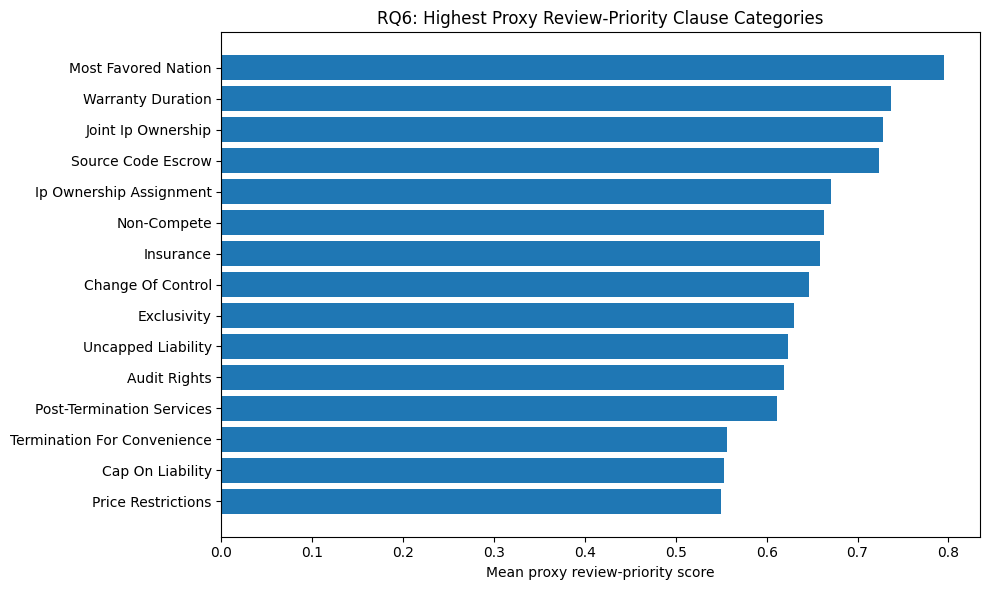

Saved figure: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\figures\rq6_fig1_proxy_risk_by_category.pdf


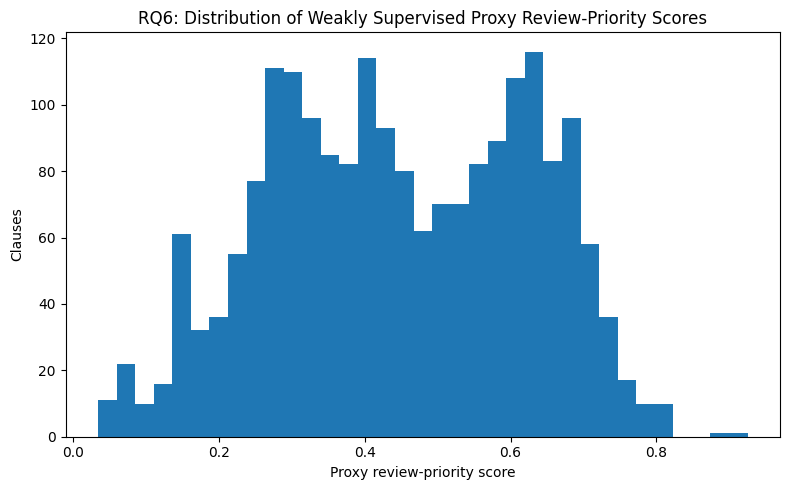

Saved figure: c:\Users\a2510\Desktop\new_code\outputs_journal_v2\figures\rq6_fig2_proxy_risk_distribution.pdf
Expected CSV output paths:
c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq6_proxy_risk_base_signals.csv
c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq6_ranked_proxy_risk_clauses_journal.csv
c:\Users\a2510\Desktop\new_code\outputs_journal_v2\csv\rq6_proxy_risk_summary_by_category.csv
Expected figure output paths:
c:\Users\a2510\Desktop\new_code\outputs_journal_v2\figures\rq6_fig1_proxy_risk_by_category.pdf
c:\Users\a2510\Desktop\new_code\outputs_journal_v2\figures\rq6_fig2_proxy_risk_distribution.pdf

RQ6 completed with journal-safe terminology and unchanged output names/locations.


In [5]:
# ============================================================
# RQ6 figures
# ------------------------------------------------------------
# Existing figure filenames are preserved exactly.
# Titles/axis labels are journal-safe: review-priority proxy,
# not true legal risk prediction.
# ============================================================

top = category_summary.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top["label"][::-1], top["mean_proxy_risk"][::-1])
plt.xlabel("Mean proxy review-priority score")
plt.title("RQ6: Highest Proxy Review-Priority Clause Categories")
savefig("rq6_fig1_proxy_risk_by_category.pdf")

plt.figure(figsize=(8, 5))
plt.hist(risk_sample["proxy_risk_score"], bins=35)
plt.xlabel("Proxy review-priority score")
plt.ylabel("Clauses")
plt.title("RQ6: Distribution of Weakly Supervised Proxy Review-Priority Scores")
savefig("rq6_fig2_proxy_risk_distribution.pdf")

# Compatibility guard: output locations and filenames intentionally unchanged.
expected_csv_outputs = [
    CSV_DIR / "rq6_proxy_risk_base_signals.csv",
    CSV_DIR / "rq6_ranked_proxy_risk_clauses_journal.csv",
    CSV_DIR / "rq6_proxy_risk_summary_by_category.csv",
]
expected_fig_outputs = [
    FIG_DIR / "rq6_fig1_proxy_risk_by_category.pdf",
    FIG_DIR / "rq6_fig2_proxy_risk_distribution.pdf",
]

print("Expected CSV output paths:")
for p in expected_csv_outputs:
    print(p)

print("Expected figure output paths:")
for p in expected_fig_outputs:
    print(p)

print("\nRQ6 completed with journal-safe terminology and unchanged output names/locations.")
